In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()

satellites = resolved[
    (resolved["IsSatellite"] == True) &
    resolved[["x", "y", "z"]].notna().all(axis=1)
].copy()

nearest_distances = []

for _, central in centrals.iterrows():

    sats = satellites[
        satellites["GroupID"] == central["GroupID"]
    ]

    if len(sats) == 0:
        nearest_distances.append(np.nan)
        continue

    box_size = 205000.0  # TNG300-1 box size in ckpc/h

    dx = np.abs(sats["x"].to_numpy() - central["x"])
    dy = np.abs(sats["y"].to_numpy() - central["y"])
    dz = np.abs(sats["z"].to_numpy() - central["z"])

    dx = np.minimum(dx, box_size - dx)
    dy = np.minimum(dy, box_size - dy)
    dz = np.minimum(dz, box_size - dz)

    distances = np.sqrt(dx**2 + dy**2 + dz**2)


    nearest_distances.append(np.min(distances))

centrals["NearestSatelliteDistance"] = nearest_distances
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Centrals: {len(centrals):,}")
print(f"DMDGS (total): {len(dmdgs):,}")
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")
print(f"DMDGS Fraction: {(len(dmdgs_non_extreme) / len(centrals)):,}")


Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"

df = pd.read_csv(CATALOG)
print(f"Total Catalog Objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")

resolved["M_star_Msun"] = (
    resolved["M_star"] * 1e10 / 0.6774
)

mass_selected = resolved[
    (resolved["M_star_Msun"] > 1e9) &
    (resolved["M_star_Msun"] < 1e10)
].copy()
satellites = mass_selected[
    mass_selected["IsSatellite"] == True
].copy()
satellites["Host_M200c_Msun"] = (
    satellites["Host_M200c"] * 1e10 / 0.6774
)
group_selected = satellites[
    satellites["Host_M200c_Msun"] > 1e13
].copy()
dmdgs = group_selected[
    group_selected["f_DM"] < 0.5
].copy()
dmdgs_non_extreme_satellites = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme_satellites):,}")

Total Catalog Objects: 13,922,457
Resolved galaxies: 154,638
DMDGS (non-tidal stripping): 400


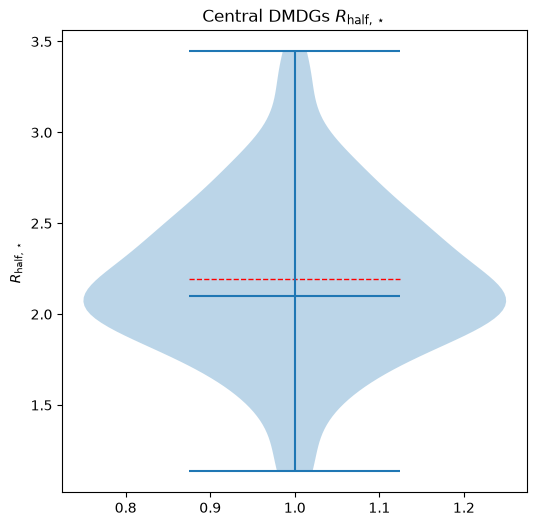

DMDGs Central Median: 2.10108815
DMDGs Central Mean: 2.19143286875


In [3]:
plt.figure(figsize=(6, 6))
vp = plt.violinplot(dmdgs_non_extreme["R_half_star"],  showmedians=True, showmeans=True,)
plt.title("Central DMDGs $R_{\\text{half}, \\star}$")
plt.ylabel("$R_{\\text{half}, \\star}$")
vp['cmeans'].set_color('red')
vp['cmeans'].set_linestyle('--')
vp['cmeans'].set_linewidth(1)
plt.ylabel("$R_{\\text{half}, \\star}$")
plt.show()
print(f"DMDGs Central Median: {dmdgs_non_extreme["R_half_star"].median()}")
print(f"DMDGs Central Mean: {dmdgs_non_extreme["R_half_star"].mean()}")

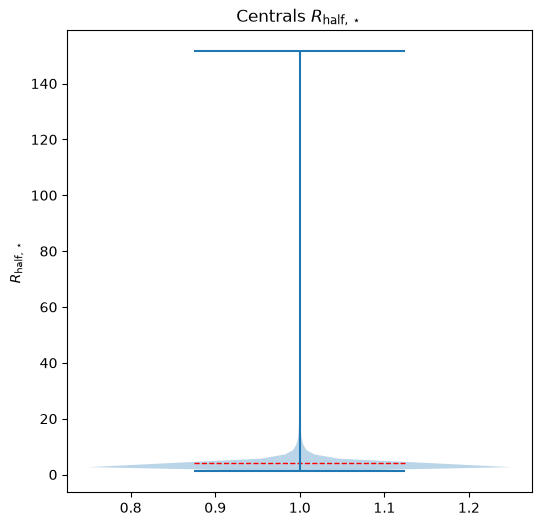

Central Median: 3.4186099
Central Mean: 4.24585662947796


In [4]:
plt.figure(figsize=(6, 6))
vp = plt.violinplot(centrals["R_half_star"], showmedians=False, showmeans=True, )
plt.title("Centrals $R_{\\text{half}, \\star}$")
plt.ylabel("$R_{\\text{half}, \\star}$")
vp['cmeans'].set_color('red')
vp['cmeans'].set_linestyle('--')
vp['cmeans'].set_linewidth(1)
plt.show()
print(f"Central Median: {centrals["R_half_star"].median()}")
print(f"Central Mean: {centrals["R_half_star"].mean()}")

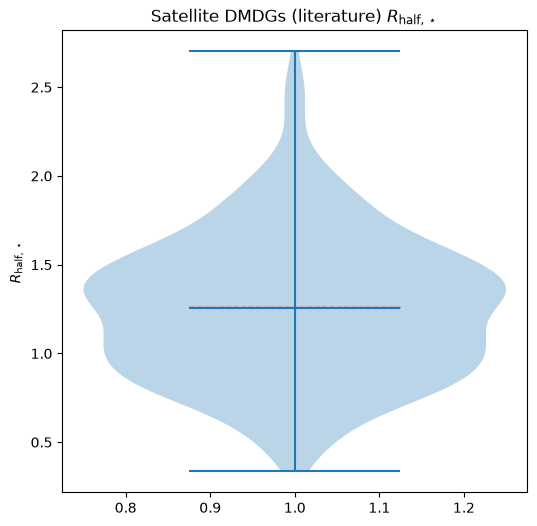

DMDG Satellites Median: 1.25728265
DMDG Satellites Mean: 1.2592683025


In [5]:
plt.figure(figsize=(6, 6))
vp = plt.violinplot(dmdgs_non_extreme_satellites["R_half_star"], showmedians=True, showmeans=True)
vp['cmeans'].set_color('red')
vp['cmeans'].set_linestyle('--')
vp['cmeans'].set_linewidth(1)
plt.title("Satellite DMDGs (literature) $R_{\\text{half}, \\star}$")
plt.ylabel("$R_{\\text{half}, \\star}$")
plt.show()
print(f"DMDG Satellites Median: {dmdgs_non_extreme_satellites["R_half_star"].median()}")
print(f"DMDG Satellites Mean: {dmdgs_non_extreme_satellites["R_half_star"].mean()}")

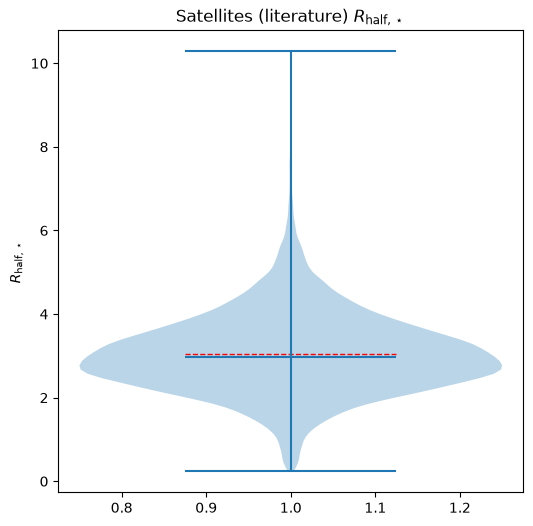

Satellites Median: 2.9663296
Satellites Mean: 3.053566942646361


In [6]:
plt.figure(figsize=(6, 6))
vp = plt.violinplot(group_selected["R_half_star"], showmedians=True, showmeans=True)
vp['cmeans'].set_color('red')
vp['cmeans'].set_linestyle('--')
vp['cmeans'].set_linewidth(1)
plt.title("Satellites (literature) $R_{\\text{half}, \\star}$")
plt.ylabel("$R_{\\text{half}, \\star}$")
plt.show()
print(f"Satellites Median: {group_selected["R_half_star"].median()}")
print(f"Satellites Mean: {group_selected["R_half_star"].mean()}")

In [7]:
from scipy import stats
import numpy as np

non_dmdg = group_selected[
    group_selected["f_DM"] >= 0.5
].copy()
dmdgs_non_extreme = dmdgs[
    dmdgs["f_DM"] >= 0.05
]
t_stat, p_value = stats.ttest_ind(dmdgs_non_extreme["R_half_star"], non_dmdg["R_half_star"], equal_var=True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the group means.")
else:
    print("Fail to reject the null hypothesis: No significant difference found.")


T-statistic: -39.933305807093156
P-value: 0.0
Reject the null hypothesis: There is a significant difference between the group means.


In [8]:
from scipy import stats
import numpy as np

non_dmdg = centrals[
    centrals["f_DM"] >= 0.5
].copy()
centralsDMDG = centrals[
   centrals["f_DM"] < 0.5
].copy()
t_stat, p_value = stats.ttest_ind(centralsDMDG["R_half_star"], non_dmdg["R_half_star"], equal_var=True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the group means.")
else:
    print("Fail to reject the null hypothesis: No significant difference found.")


T-statistic: -5.304530588192812
P-value: 1.1322072060715197e-07
Reject the null hypothesis: There is a significant difference between the group means.
